# 01 · Gerçek İHA verisi
Aşama 3: Kaggle'dan indirilen küçük paketle (`data/kucuk_paket`) gerçek fotoğrafları ve etiketlerini incelemek.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

(512, 640, 3)


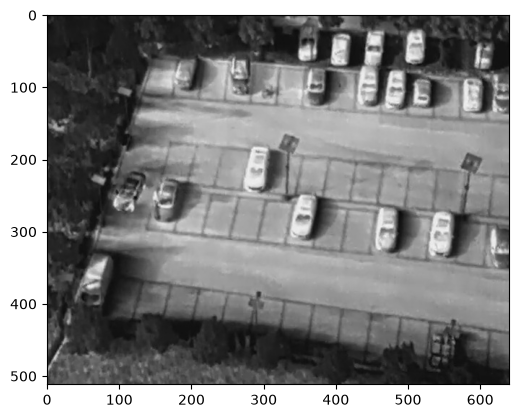

512 640
21
1 0.564844 0.076172 0.045313 0.101562


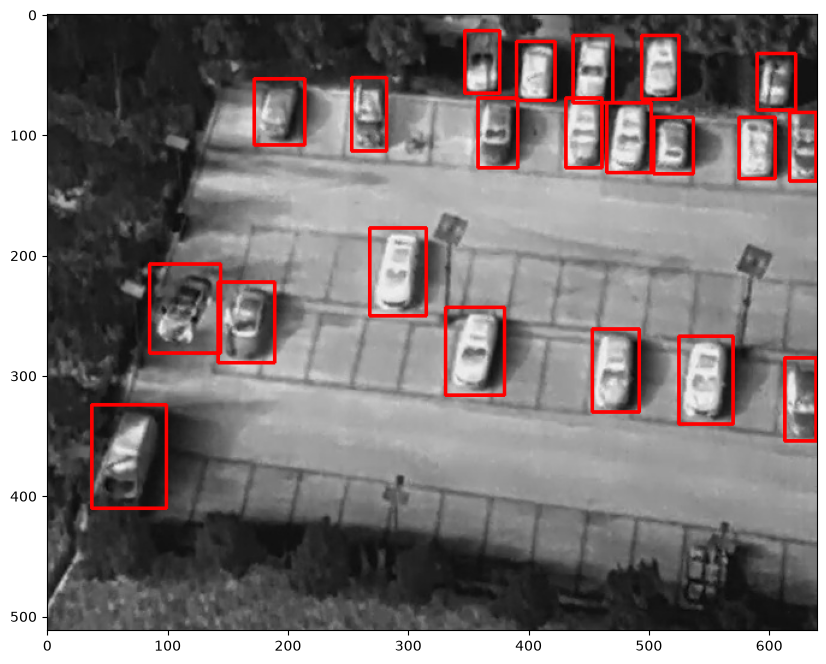

car
other_vehicle
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
3 other_vehicle


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import cv2


def yolo_kutu(satir, genislik, yukseklik):
    parcalar = satir.split()

    mx = float(parcalar[1]) * genislik     # merkez x (piksel)
    my = float(parcalar[2]) * yukseklik    # merkez y (piksel)
    g  = float(parcalar[3]) * genislik     # kutu genişliği (piksel)
    y  = float(parcalar[4]) * yukseklik    # kutu yüksekliği (piksel)

    x1 = round(mx - g / 2)
    y1 = round(my - y / 2)
    x2 = round(mx + g / 2)
    y2 = round(my + y / 2)

    return x1, y1, x2, y2


ad = "02_hituav__0_100_50_0_08164__c5427da128"

foto = cv2.imread("../data/kucuk_paket/images/train/" + ad + ".png")

print(foto.shape)
plt.imshow(cv2.cvtColor(foto, cv2.COLOR_BGR2RGB))
plt.show()


yukseklik = foto.shape[0]
genislik  = foto.shape[1]

print(yukseklik, genislik)


with open("../data/kucuk_paket/labels/train/" + ad + ".txt") as dosya:
    etiketler = dosya.read().splitlines()

    print(len(etiketler))
    print(etiketler[0])



    cizim = foto.copy()

for satir in etiketler:
    x1, y1, x2, y2 = yolo_kutu(satir, genislik, yukseklik)
    cv2.rectangle(cizim, (x1, y1), (x2, y2), (0, 0, 255), 2)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(cizim, cv2.COLOR_BGR2RGB))
plt.show()


siniflar = {
    0: "person",
    1: "car",
    2: "bicycle",
    3: "other_vehicle",
    4: "drone",
    5: "mine",
    6: "gun",
}

print(siniflar[1])
print(siniflar[3])


for satir in etiketler:
    numara = int(satir.split()[0])
    print(numara, siniflar[numara])

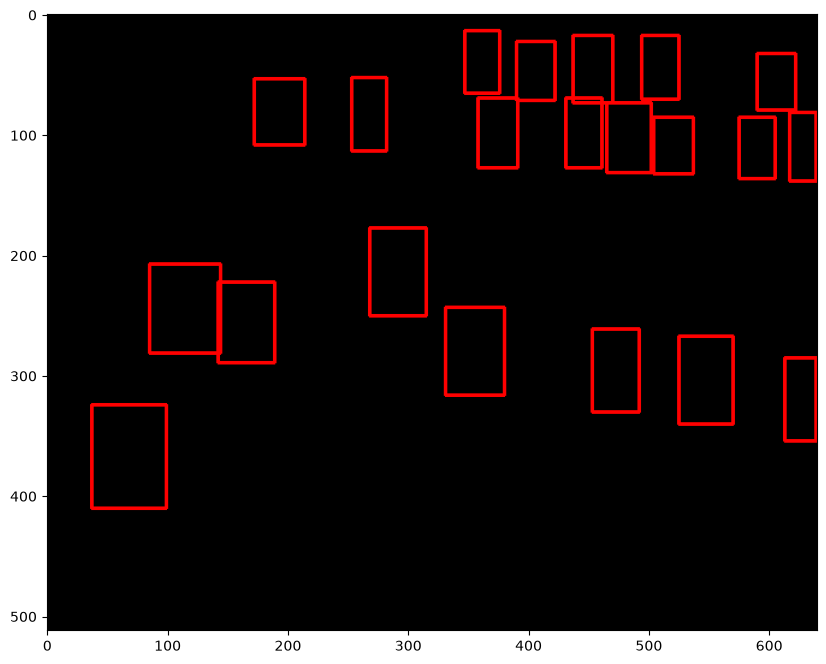

In [7]:
bos = np.zeros((512, 640, 3), dtype=np.uint8)

for satir in etiketler:
    x1, y1, x2, y2 = yolo_kutu(satir, 640, 512)
    cv2.rectangle(bos, (x1, y1), (x2, y2), (0, 0, 255), 2)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(bos, cv2.COLOR_BGR2RGB))
plt.show()

(512, 640, 3)


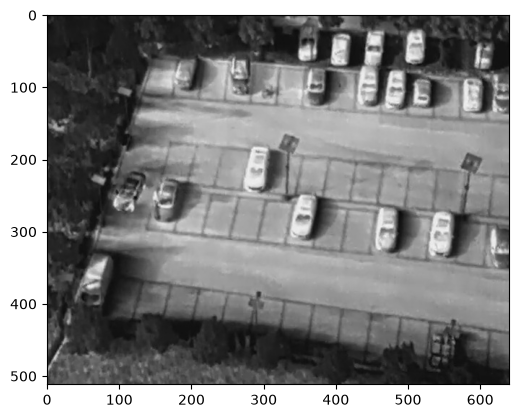

512 640
21
1 0.564844 0.076172 0.045313 0.101562


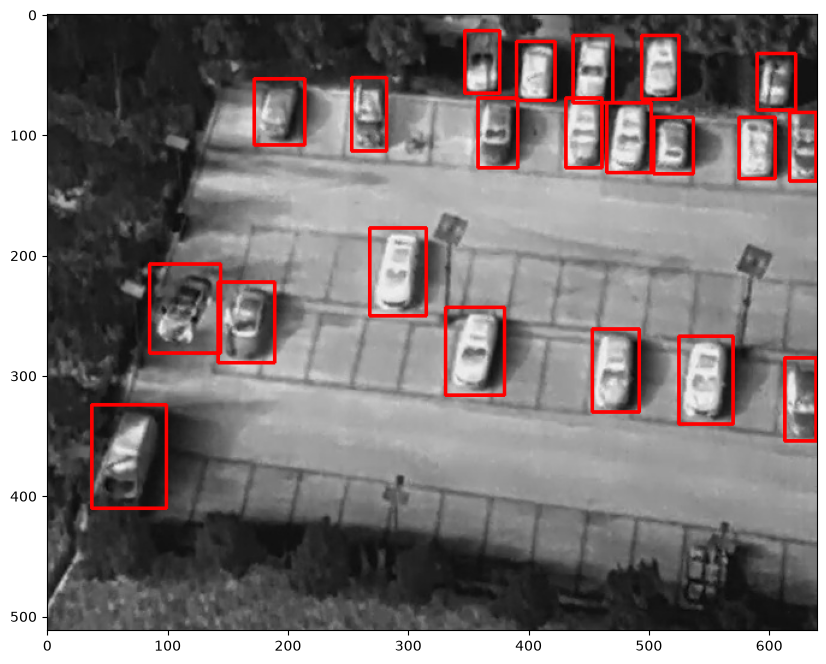

car
other_vehicle
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
1 car
3 other_vehicle


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import cv2


def yolo_kutu(satir, genislik, yukseklik):
    parcalar = satir.split()

    mx = float(parcalar[1]) * genislik     # merkez x (piksel)
    my = float(parcalar[2]) * yukseklik    # merkez y (piksel)
    g  = float(parcalar[3]) * genislik     # kutu genişliği (piksel)
    y  = float(parcalar[4]) * yukseklik    # kutu yüksekliği (piksel)

    x1 = round(mx - g / 2)
    y1 = round(my - y / 2)
    x2 = round(mx + g / 2)
    y2 = round(my + y / 2)

    return x1, y1, x2, y2


ad = "02_hituav__0_100_50_0_08164__c5427da128"

foto = cv2.imread("../data/kucuk_paket/images/train/" + ad + ".png")

print(foto.shape)
plt.imshow(cv2.cvtColor(foto, cv2.COLOR_BGR2RGB))
plt.show()


yukseklik = foto.shape[0]
genislik  = foto.shape[1]

print(yukseklik, genislik)


with open("../data/kucuk_paket/labels/train/" + ad + ".txt") as dosya:
    etiketler = dosya.read().splitlines()

    print(len(etiketler))
    print(etiketler[0])



    cizim = foto.copy()

for satir in etiketler:
    x1, y1, x2, y2 = yolo_kutu(satir, genislik, yukseklik)
    cv2.rectangle(cizim, (x1, y1), (x2, y2), (0, 0, 255), 2)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(cizim, cv2.COLOR_BGR2RGB))
plt.show()


siniflar = {
    0: "person",
    1: "car",
    2: "bicycle",
    3: "other_vehicle",
    4: "drone",
    5: "mine",
    6: "gun",
}

print(siniflar[1])
print(siniflar[3])


for satir in etiketler:
    numara = int(satir.split()[0])
    print(numara, siniflar[numara])